<a href="https://colab.research.google.com/github/anitha6752/DAP_intership_tasks/blob/main/Task2_%3D_Predictive_Analysis_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


from google.colab import files
uploaded = files.upload()

Upload widget is only available when the cell has been executed in the current browser session. Please rerun this cell to enable.
Saving top-5000-youtube-channels.csv to top-5000-youtube-channels.csv

df = pd.read_csv('/top-5000-youtube-channels.csv')
df.head()

Saving top-5000-youtube-channels.csv to top-5000-youtube-channels.csv


,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
0,1st,A++,Zee TV,82757,18752951,20869786591
1,2nd,A++,T-Series,12661,61196302,47548839843
2,3rd,A++,Cocomelon - Nursery Rhymes,373,19238251,9793305082
3,4th,A++,SET India,27323,31180559,22675948293
4,5th,A++,WWE,36756,32852346,26273668433


In [6]:
def convert_str_to_num(x):
    if isinstance(x, str):
        x = x.replace(',', '')
        if 'K' in x:
            return float(x.replace('K', ''))* 1_000
        elif 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        elif 'B' in x:
            return float(x.replace('B', '')) * 1_000_000_000
    try:
        return float(x)
    except:
        return np.nan


In [7]:
df['Subscribers'] = df['Subscribers'].apply(convert_str_to_num)
df['Video views'] = df['Video views'].apply(convert_str_to_num)
df['Video Uploads'] = df['Video Uploads'].apply(convert_str_to_num)

In [8]:
df.dropna(subset=['Subscribers', 'Video views', 'Video Uploads'], inplace=True)

In [9]:
X = df[['Video views', 'Video Uploads']]
y = df['Subscribers']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.


RandomForestRegressor()

In [13]:

y_pred = model.predict(X_test)

In [14]:
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.5575276190218825
Mean Squared Error: 5665639473295.18


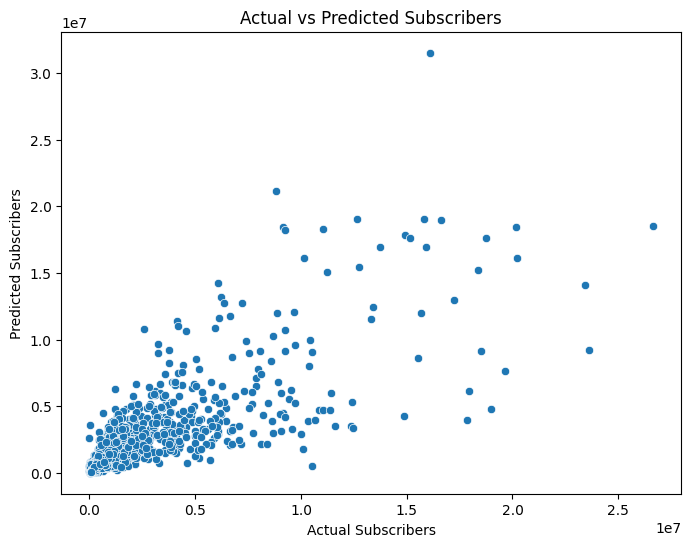

In [15]:

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Subscribers")
plt.ylabel("Predicted Subscribers")
plt.title("Actual vs Predicted Subscribers")
plt.show()